# Static Analysis (Reduced)

## Output Maps (7)
1. Annual average activity (inflow + outflow) by station
2. Annual average inflow - outflow difference map by station
3. Annual average inflow/outflow log-ratio map by station
4. Annual average weekend - weekday activity difference map by station
5. Annual average log(weekend/weekday activity) map by station
6. Morning RH (07:00-08:59) annual average inflow/outflow log-ratio map by station
7. Evening RH (17:00-18:59) annual average inflow/outflow log-ratio map by station


## 1. Setup and Data Loading


In [21]:
import glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import pyarrow.parquet as pq
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram
import mapclassify
from matplotlib_scalebar.scalebar import ScaleBar

BASE_DIR = Path('.')
INPUT_DIR = BASE_DIR / 'input'
TRIP_DIR = INPUT_DIR / 'trip_parquet'

station = pd.read_csv(INPUT_DIR / 'Station.csv', encoding='euc-kr')
seoul = gpd.read_file(INPUT_DIR / 'bnd/seoul.shp')
seoul_stream = gpd.read_file(INPUT_DIR / 'bnd/seoul_stream.shp')
files = sorted(glob.glob(str(TRIP_DIR / 'trip_2025-*.parquet')))

station.columns = ['stationID', 'address1', 'address2', 'lat', 'long']
station = station[['stationID', 'lat', 'long']]
station = station[(station['lat'] != 0) & (station['long'] != 0)].copy()

station_gdf = gpd.GeoDataFrame(
    station,
    geometry=gpd.points_from_xy(station['long'], station['lat']),
    crs='EPSG:4326'
).to_crs(epsg=5179)
station_gdf = gpd.clip(station_gdf, seoul)

points = MultiPoint(station_gdf.geometry.tolist())
vor = voronoi_diagram(points)
station_vor = gpd.GeoDataFrame(geometry=list(vor.geoms), crs=station_gdf.crs)
station_vor = gpd.sjoin(
    station_vor,
    station_gdf[['stationID', 'geometry']],
    how='left',
    predicate='contains'
)
station_vor_clip = gpd.clip(station_vor, seoul)

print('Stations in Seoul:', len(station_gdf))
print('Trip parquet files:', len(files))


Stations in Seoul: 3329
Trip parquet files: 365


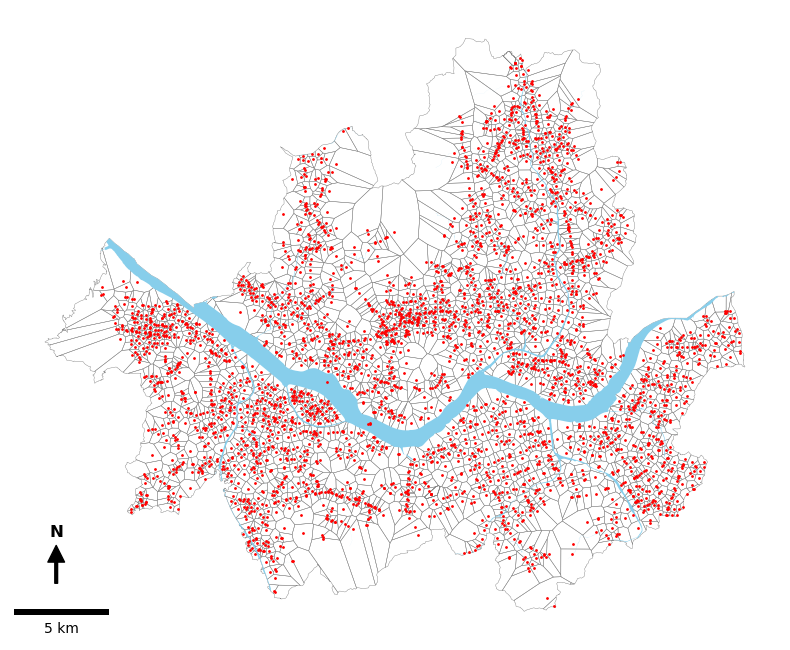

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

station_vor_clip.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.3)
seoul_stream.plot(ax=ax, color='skyblue', linewidth=1)
station_gdf.plot(ax=ax, color='red', markersize=1)

scalebar = ScaleBar(dx=1, units='m', location='lower left', box_alpha=0.5)
ax.add_artist(scalebar)

ax.annotate(
    '',
    xy=(0.06, 0.15),
    xytext=(0.06, 0.09),
    arrowprops=dict(
        facecolor='black',
        edgecolor='black',
        width=2,
        headwidth=12
    ),
    xycoords=ax.transAxes
)

ax.text(
    0.06, 0.16,
    'N',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [5]:
def read_and_filter_trip(parquet_file):
    table = pq.read_table(parquet_file)
    df = table.to_pandas(types_mapper=None)
    return df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)].copy()


total_filtered = 0
for f in files:
    total_filtered += len(read_and_filter_trip(f))

print('Total filtered trips in 2025:', total_filtered)


Total filtered trips in 2025: 36298179


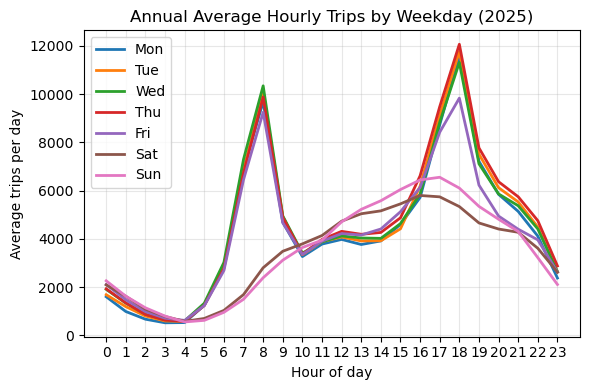

In [43]:
# agg = np.zeros((7, 24), dtype=np.float64)
# weekday_file_count = np.zeros(7, dtype=int)

# for f in files:
#     df = read_and_filter_trip(f)
#     df['weekday'] = df['RENT_DT'].dt.weekday
#     df['hour'] = df['RENT_DT'].dt.hour

#     wd = int(df['weekday'].iloc[0])
#     weekday_file_count[wd] += 1

#     counts = df.groupby(['weekday', 'hour']).size()
#     for (w, h), val in counts.items():
#         agg[w, h] += val

# avg_agg = np.zeros_like(agg)
# for w in range(7):
#     if weekday_file_count[w] > 0:
#         avg_agg[w, :] = agg[w, :] / weekday_file_count[w]

# hourly_avg = pd.DataFrame(
#     avg_agg,
#     index=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
#     columns=range(24)
# )

fig, ax = plt.subplots(figsize=(6, 4))

for wd in range(7):
    ax.plot(
        range(24),
        hourly_avg.iloc[wd],
        label=hourly_avg.index[wd],
        linewidth=2
    )

ax.set_xlabel('Hour of day')
ax.set_ylabel('Average trips per day')
ax.set_xticks(range(24))
ax.set_title('Annual Average Hourly Trips by Weekday (2025)')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


## 2. Build Comprehensive GeoDataFrame (All Metrics First)


In [7]:
def read_and_filter_trip(parquet_file):
    table = pq.read_table(parquet_file)
    df = table.to_pandas(types_mapper=None)
    if not pd.api.types.is_datetime64_any_dtype(df['RENT_DT']):
        df['RENT_DT'] = pd.to_datetime(df['RENT_DT'])
    return df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)].copy()


def add_counts(acc, series):
    for sid, val in series.items():
        acc[sid] += int(val)


def log_ratio(numerator, denominator, eps=1.0):
    return np.log((numerator + eps) / (denominator + eps))


In [8]:
annual_inflow_sum = defaultdict(int)
annual_outflow_sum = defaultdict(int)

wd_inflow_sum = defaultdict(int)
wd_outflow_sum = defaultdict(int)
we_inflow_sum = defaultdict(int)
we_outflow_sum = defaultdict(int)

mr_inflow_sum = defaultdict(int)
mr_outflow_sum = defaultdict(int)
er_inflow_sum = defaultdict(int)
er_outflow_sum = defaultdict(int)

weekday_days = 0
weekend_days = 0

for f in files:
    df = read_and_filter_trip(f)

    add_counts(annual_inflow_sum, df.groupby('RETURN_STATION_ID').size())
    add_counts(annual_outflow_sum, df.groupby('RENT_STATION_ID').size())

    day_type = int(df['RENT_DT'].dt.weekday.iloc[0])
    if day_type < 5:
        weekday_days += 1
        add_counts(wd_inflow_sum, df.groupby('RETURN_STATION_ID').size())
        add_counts(wd_outflow_sum, df.groupby('RENT_STATION_ID').size())
    else:
        weekend_days += 1
        add_counts(we_inflow_sum, df.groupby('RETURN_STATION_ID').size())
        add_counts(we_outflow_sum, df.groupby('RENT_STATION_ID').size())

    hours = df['RENT_DT'].dt.hour
    morning_df = df[hours.isin([7, 8])]
    evening_df = df[hours.isin([17, 18])]

    add_counts(mr_inflow_sum, morning_df.groupby('RETURN_STATION_ID').size())
    add_counts(mr_outflow_sum, morning_df.groupby('RENT_STATION_ID').size())
    add_counts(er_inflow_sum, evening_df.groupby('RETURN_STATION_ID').size())
    add_counts(er_outflow_sum, evening_df.groupby('RENT_STATION_ID').size())

n_days = len(files)

station_ids = sorted(
    set(station_vor_clip['stationID'].dropna().unique())
    | set(annual_inflow_sum) | set(annual_outflow_sum)
    | set(wd_inflow_sum) | set(wd_outflow_sum)
    | set(we_inflow_sum) | set(we_outflow_sum)
    | set(mr_inflow_sum) | set(mr_outflow_sum)
    | set(er_inflow_sum) | set(er_outflow_sum)
)

stats = pd.DataFrame({'stationID': station_ids})

stats['avg_inflow'] = stats['stationID'].map(lambda x: annual_inflow_sum[x] / n_days)
stats['avg_outflow'] = stats['stationID'].map(lambda x: annual_outflow_sum[x] / n_days)
stats['avg_activity'] = stats['avg_inflow'] + stats['avg_outflow']
stats['diff_in_out'] = stats['avg_inflow'] - stats['avg_outflow']
stats['log_ratio_in_out'] = log_ratio(stats['avg_inflow'], stats['avg_outflow'])

stats['wd_avg_inflow'] = stats['stationID'].map(lambda x: wd_inflow_sum[x] / weekday_days if weekday_days else 0)
stats['wd_avg_outflow'] = stats['stationID'].map(lambda x: wd_outflow_sum[x] / weekday_days if weekday_days else 0)
stats['we_avg_inflow'] = stats['stationID'].map(lambda x: we_inflow_sum[x] / weekend_days if weekend_days else 0)
stats['we_avg_outflow'] = stats['stationID'].map(lambda x: we_outflow_sum[x] / weekend_days if weekend_days else 0)

stats['wd_avg_activity'] = stats['wd_avg_inflow'] + stats['wd_avg_outflow']
stats['we_avg_activity'] = stats['we_avg_inflow'] + stats['we_avg_outflow']
stats['diff_we_wd_activity'] = stats['we_avg_activity'] - stats['wd_avg_activity']
stats['log_ratio_we_wd_activity'] = log_ratio(stats['we_avg_activity'], stats['wd_avg_activity'])

stats['mr_avg_inflow'] = stats['stationID'].map(lambda x: mr_inflow_sum[x] / n_days)
stats['mr_avg_outflow'] = stats['stationID'].map(lambda x: mr_outflow_sum[x] / n_days)
stats['log_ratio_mr_in_out'] = log_ratio(stats['mr_avg_inflow'], stats['mr_avg_outflow'])

stats['er_avg_inflow'] = stats['stationID'].map(lambda x: er_inflow_sum[x] / n_days)
stats['er_avg_outflow'] = stats['stationID'].map(lambda x: er_outflow_sum[x] / n_days)
stats['log_ratio_er_in_out'] = log_ratio(stats['er_avg_inflow'], stats['er_avg_outflow'])

comprehensive_gdf = station_vor_clip.merge(stats, on='stationID', how='left').fillna(0)

print('Total days:', n_days)
print('Weekday days:', weekday_days)
print('Weekend days:', weekend_days)
comprehensive_gdf[[
    'stationID', 'avg_activity', 'diff_in_out', 'log_ratio_in_out',
    'diff_we_wd_activity', 'log_ratio_we_wd_activity',
    'log_ratio_mr_in_out', 'log_ratio_er_in_out'
]].head()



Total days: 365
Weekday days: 261
Weekend days: 104


,stationID,avg_activity,diff_in_out,log_ratio_in_out,diff_we_wd_activity,log_ratio_we_wd_activity,log_ratio_mr_in_out,log_ratio_er_in_out
0,ST-1932,9.564384,0.128767,0.022271,-1.448165,-0.141480,0.270691,-0.002653
1,ST-1648,15.419178,1.150685,0.132310,0.072686,0.004423,0.361235,0.298251
2,ST-1956,4.495890,-0.413699,-0.127545,0.167109,0.030211,-0.250428,0.065771
3,ST-1955,20.852055,-0.764384,-0.066923,-5.292846,-0.256928,-0.016829,0.076316
4,ST-3067,29.991781,0.128767,0.008050,-15.546456,-0.577855,0.607673,-1.472517


## 3. Plot Maps (7)


/Users/yunsik/miniconda3/envs/geovis/lib/python3.11/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


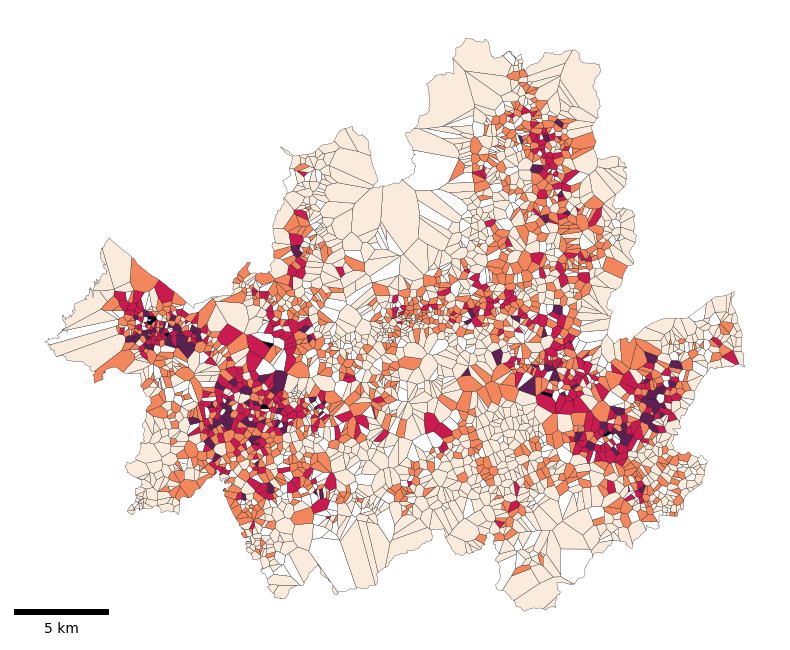

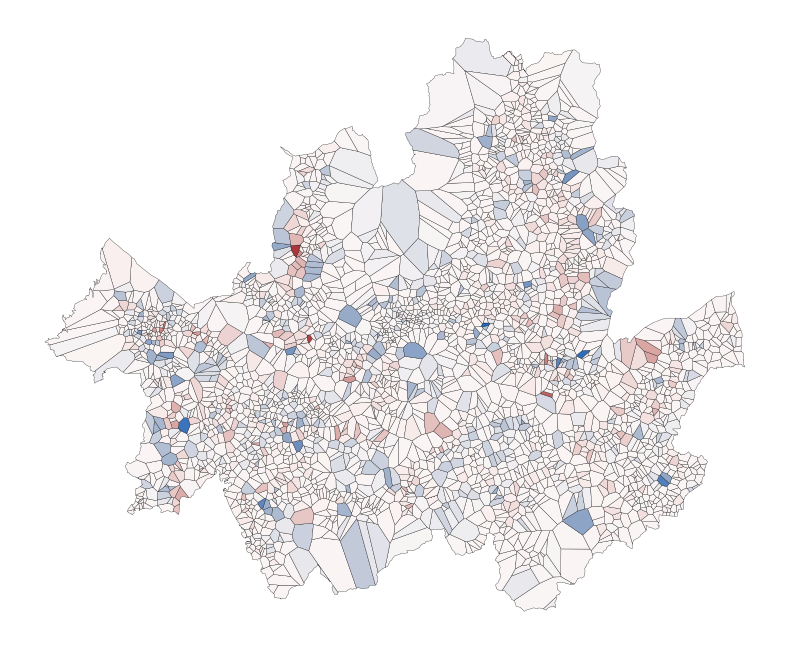

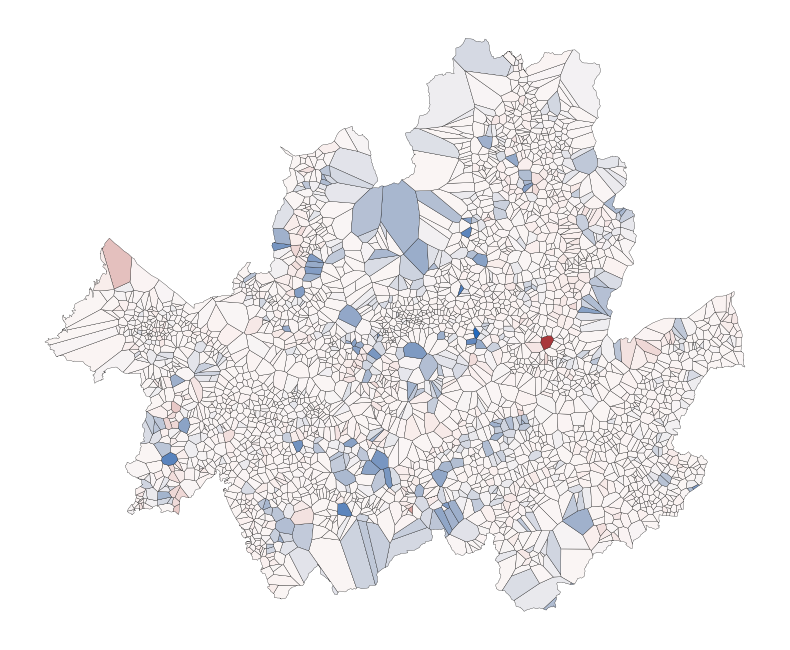

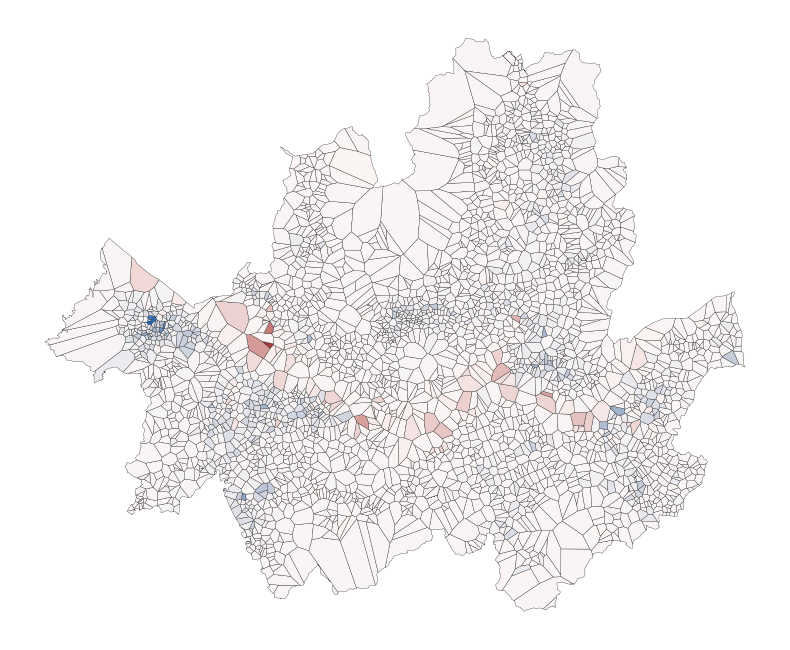

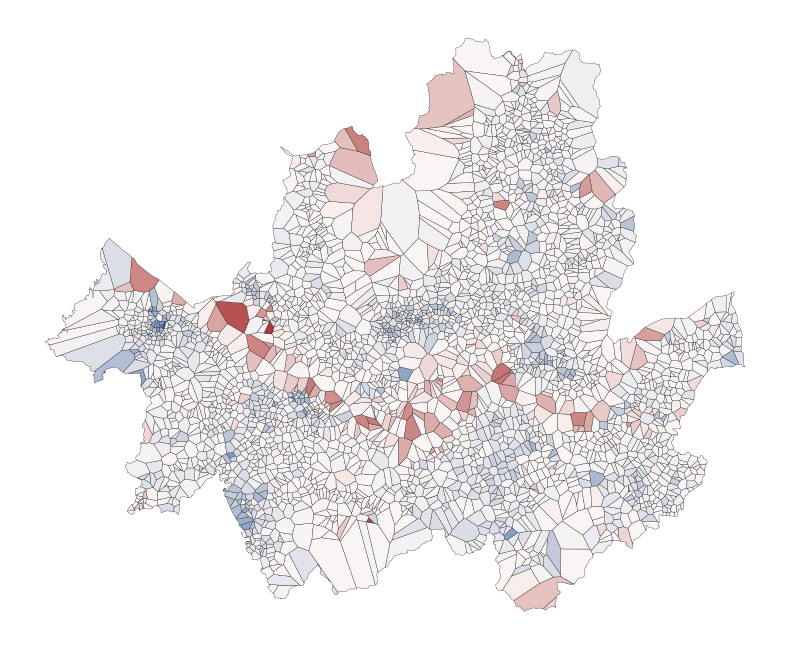

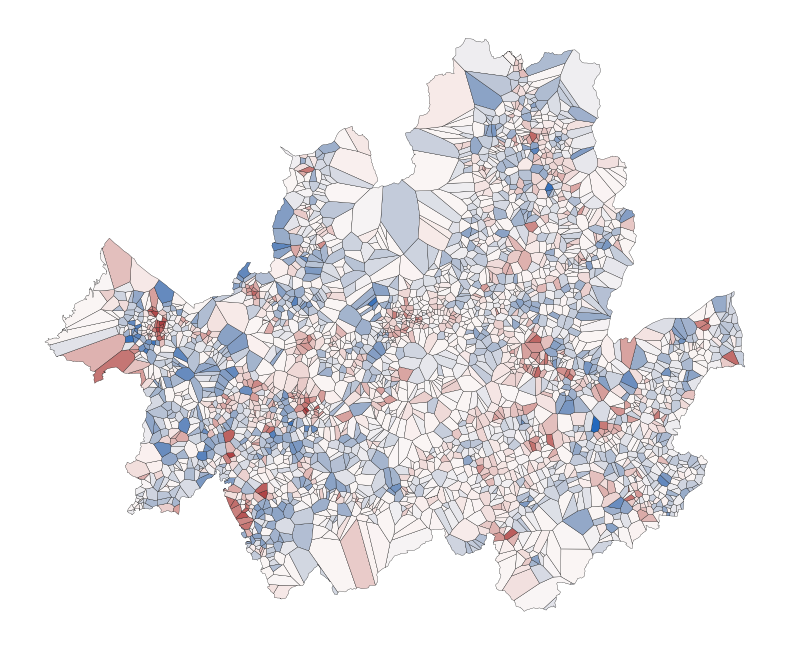

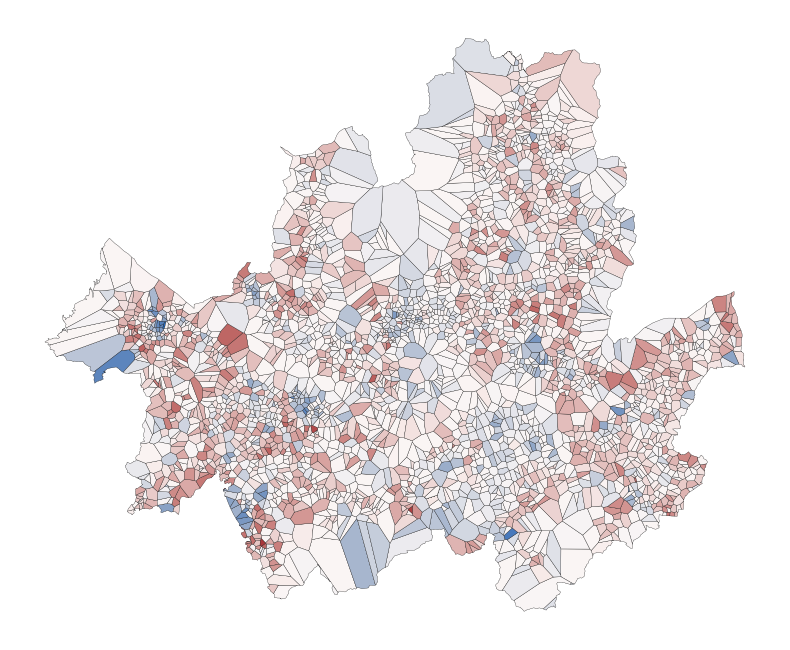

In [45]:
import mapclassify

def plot_continuous_map(gdf, column, title, cmap, center=None, k=5):
    s = gdf[column].replace([np.inf, -np.inf], np.nan)
    valid = s.dropna()

    fig, ax = plt.subplots(figsize=(8, 8))

    if center is None:
        # 🔹 0값 분리
        zero_data = gdf[gdf[column] == 0]
        nonzero_data = gdf[gdf[column] != 0].copy()

        # 0은 흰색
        zero_data.plot(
            ax=ax,
            color='white',
            edgecolor='black',
            linewidth=0.2
        )

        if not nonzero_data.empty:
            # 🔹 Fisher–Jenks classification
            classes = max(1, min(k, nonzero_data[column].nunique()))

            nonzero_data.plot(
                column=column,
                scheme='FisherJenks',
                k=classes,
                cmap=cmap,
                legend=False,
                ax=ax,
                edgecolor='black',
                linewidth=0.2
            )


            scalebar = ScaleBar(dx=1, units='m', location='lower left', box_alpha=0.5)
            ax.add_artist(scalebar)

    else:
        # 🔹 Diverging map (continuous 유지)
        vmin = float(valid.min())
        vmax = float(valid.max())
        if vmin == vmax:
            vmin = center - 0.01
            vmax = center + 0.01

        norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)

        gdf.plot(
            column=column,
            cmap=cmap,
            norm=norm,
            legend=False,
            ax=ax,
            edgecolor='black',
            linewidth=0.2,
            missing_kwds={'color': 'white'}
        )

    # ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


seq_cmap = sns.color_palette('rocket_r', as_cmap=True)
div_cmap = sns.color_palette('vlag', as_cmap=True)

plot_continuous_map(
    comprehensive_gdf,
    'avg_activity',
    '1) Annual Average Activity (Inflow + Outflow)',
    cmap=seq_cmap
)

plot_continuous_map(
    comprehensive_gdf,
    'diff_in_out',
    '2) Annual Average Inflow - Outflow Difference',
    cmap=div_cmap,
    center=0
)

plot_continuous_map(
    comprehensive_gdf,
    'log_ratio_in_out',
    '3) Annual Average log(Inflow / Outflow)',
    cmap=div_cmap,
    center=0
)

plot_continuous_map(
    comprehensive_gdf,
    'diff_we_wd_activity',
    '4) Annual Average Weekend - Weekday Activity Difference',
    cmap=div_cmap,
    center=0
)

plot_continuous_map(
    comprehensive_gdf,
    'log_ratio_we_wd_activity',
    '5) Annual Average log(Weekend / Weekday Activity)',
    cmap=div_cmap,
    center=0
)


plot_continuous_map(
    comprehensive_gdf,
    'log_ratio_mr_in_out',
    '6) Morning RH (07:00-08:59) Annual Average log(Inflow / Outflow)',
    cmap=div_cmap,
    center=0
)

plot_continuous_map(
    comprehensive_gdf,
    'log_ratio_er_in_out',
    '7) Evening RH (17:00-18:59) Annual Average log(Inflow / Outflow)',
    cmap=div_cmap,
    center=0
)

